# Data And Preprocessing

В этом ноутбуке подготавливаются данные для `RNN`-baseline в курсовой работе по пользовательским эмбеддингам на последовательностях игровых событий.

Цель этапа:
- зафиксировать единый preprocessing;
- построить пользовательские последовательности событий;
- сделать воспроизводимый `train/val/test` split по пользователям;
- сохранить артефакты для последующих этапов обучения и оценки.


## План

1. Загрузить и очистить события.
2. Кратко описать текущий срез данных.
3. Построить последовательности пользователей.
4. Зафиксировать split по пользователям.
5. Сохранить артефакты preprocessing в `artifacts/data/`.


In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import polars as pl

from src.data import (
    build_user_sequences,
    load_clean_event_logs,
    preprocess_event_logs_to_parquet,
    save_prepared_sequences,
    summarize_event_logs,
    summarize_sequence_lengths,
)
from src.splits import build_user_split, save_user_split_tables, describe_user_split

plt.style.use('seaborn-v0_8-whitegrid')
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(20)

polars.config.Config

In [ ]:
USE_FULL_DATA = True
SAMPLE_DATA_PATH = PROJECT_ROOT / 'events_sample.csv'

if USE_FULL_DATA:
    import kagglehub
    full_data_dir = Path(kagglehub.dataset_download('alekseipetrakov/events'))
    matches = sorted(full_data_dir.rglob('events*.csv'))
    if not matches:
        raise FileNotFoundError(f'events*.csv not found under {full_data_dir}')
    RAW_DATA_PATH = matches[0]
else:
    RAW_DATA_PATH = SAMPLE_DATA_PATH

if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found: {RAW_DATA_PATH}')
ARTIFACTS_DATA_DIR = PROJECT_ROOT / 'artifacts' / 'data'
CLEAN_EVENTS_DIR = ARTIFACTS_DATA_DIR / 'clean_events'

SEED = 42
MIN_EVENTS_PER_USER = 10
VAL_RATIO = 0.15
TEST_RATIO = 0.15
PREPROCESS_CHUNK_SIZE = 50_000 if not USE_FULL_DATA else 250_000

print(f'RAW_DATA_PATH={RAW_DATA_PATH}')
print(f'USE_FULL_DATA={USE_FULL_DATA}')
print(f'ARTIFACTS_DATA_DIR={ARTIFACTS_DATA_DIR}')
print(f'PREPROCESS_CHUNK_SIZE={PREPROCESS_CHUNK_SIZE}')
print(f'SEED={SEED}, MIN_EVENTS_PER_USER={MIN_EVENTS_PER_USER}, VAL_RATIO={VAL_RATIO}, TEST_RATIO={TEST_RATIO}')

RAW_DATA_PATH=/Users/fedornikonov/.cache/kagglehub/datasets/alekseipetrakov/events/versions/1/events (1).csv
USE_FULL_DATA=True
ARTIFACTS_DATA_DIR=/Users/fedornikonov/hse_recsys_rnn/artifacts/data
PREPROCESS_CHUNK_SIZE=250000
SEED=42, MIN_EVENTS_PER_USER=10, VAL_RATIO=0.15, TEST_RATIO=0.15


## 1. Загрузка и очистка событий

На этом шаге удаляются технические и служебные события, строки приводятся к корректным типам, а события внутри пользователей упорядочиваются по времени.


In [3]:
ARTIFACTS_DATA_DIR.mkdir(parents=True, exist_ok=True)
legacy_clean_path = ARTIFACTS_DATA_DIR / 'clean_events.parquet'
if legacy_clean_path.exists():
    legacy_clean_path.unlink()

preprocess_paths = preprocess_event_logs_to_parquet(
    RAW_DATA_PATH,
    ARTIFACTS_DATA_DIR,
    chunk_size=PREPROCESS_CHUNK_SIZE,
    overwrite=True,
)

df = load_clean_event_logs(CLEAN_EVENTS_DIR)
print(df.shape)
df.head(10)

(51102463, 7)


row_id,appmetrica_device_id,event_name,event_json,event_datetime,event_timestamp,session_id
u32,str,str,str,str,i64,i64
60917895,"""10000235382394935150""","""Mount Garage""","""{""tierUp"":{""1"":""0""}}""","""2026-03-16 19:09:46""",1773673786,10000000001
60923819,"""10000235382394935150""","""machine_learning""","""{""init_event"":{""session_cnt"":""…","""2026-03-16 19:09:48""",1773673788,10000000001
60920982,"""10000235382394935150""","""REWARD""","""{""LOADED"":"""",""PlayTimeMinutes""…","""2026-03-16 19:10:01""",1773673801,10000000001
60920983,"""10000235382394935150""","""REWARD""","""{""ButtonShown"":""Money"",""PlayTi…","""2026-03-16 19:10:18""",1773673818,10000000001
67578758,"""10000279983408954705""","""Mount Garage""","""{""tierUp"":{""1"":""0""}}""","""2026-03-28 17:48:27""",1774705707,10000000001
67581213,"""10000279983408954705""","""machine_learning""","""{""init_event"":{""session_cnt"":""…","""2026-03-28 17:48:33""",1774705713,10000000001
67578578,"""10000279983408954705""","""Gate""","""{""Gate unlocked"":{""0"":""0""}}""","""2026-03-28 17:49:19""",1774705759,10000000001
67579233,"""10000279983408954705""","""Quests""","""{""Complete_Step_Quest1"":{""Ques…","""2026-03-28 17:49:19""",1774705759,10000000001
67579234,"""10000279983408954705""","""Quests""","""{""Biker quest"":""1"",""PlayTimeMi…","""2026-03-28 17:51:31""",1774705891,10000000001


In [4]:
event_summary = summarize_event_logs(df)
event_summary

metric,value
str,i64
"""rows""",51102463
"""users""",67055
"""unique_events""",81
"""min_timestamp""",1772136000
"""max_timestamp""",1774814007
"""sessions""",3488


Вывод.

После фильтрации и удаления технических/служебных событий в рабочем наборе осталось **51,102,463** событий, относящихся к **67,055** пользователям и **81** типу событий. Это означает, что даже после очистки датасет остаётся достаточно крупным для обучения последовательностной модели, а сама фильтрация не разрушает поведенческий сигнал, а только убирает явный шум.


## 2. Focused EDA

Здесь оставлен только тот анализ, который влияет на моделирование: частоты событий и длины пользовательских историй.


In [5]:
top_events = (
    df.group_by('event_name')
    .len()
    .sort('len', descending=True)
    .head(20)
)

top_events

event_name,len
str,u32
"""REWARD""",12722794
"""machine_learning""",7670256
"""Training""",7218253
"""Equipment levels""",4401100
"""Coffee""",4247142
"""Equipment merges""",3886138
"""itemsDropEmission""",1906584
"""Gun Store""",1334316
"""Mount Garage""",872064


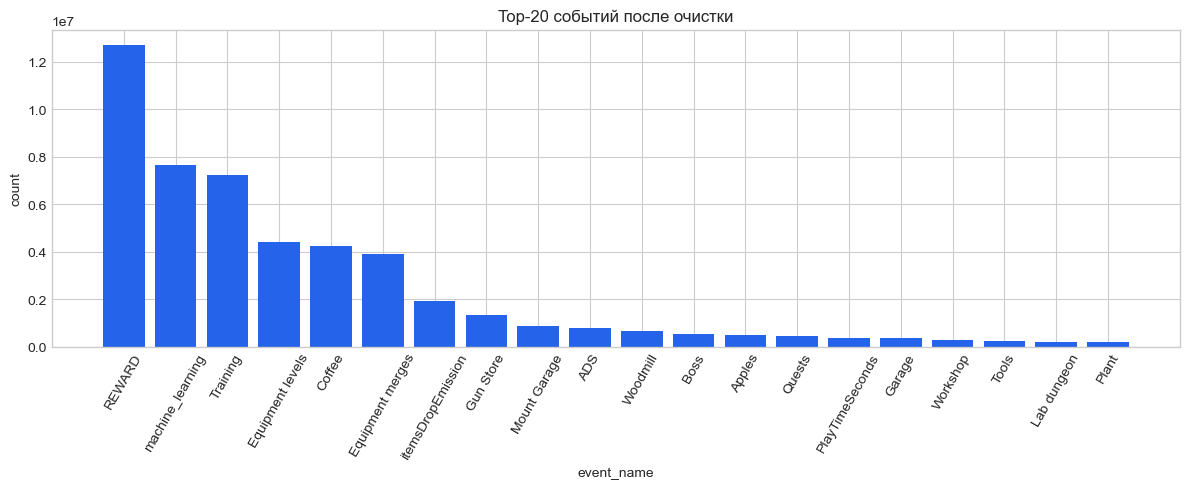

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_events['event_name'].to_list(), top_events['len'].to_list(), color='#2563eb')
ax.set_title('Top-20 событий после очистки')
ax.set_xlabel('event_name')
ax.set_ylabel('count')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.show()

Вывод.

Распределение частот событий остаётся сильно неравномерным: наиболее частые токены, такие как `REWARD`, `machine_learning` и `Training`, покрывают значительную долю логов. При этом топ событий уже выглядит содержательно и отражает игровые действия, а не служебные процессы. Это важно для baseline-модели: с одной стороны, данные несбалансированы, с другой стороны, словарь после очистки стал интерпретируемым и пригодным для построения последовательностей.


## 3. Построение пользовательских последовательностей

На этом шаге каждое событие кодируется индексом, после чего для каждого пользователя строится упорядоченная последовательность событий. Пользователи с очень короткой историей исключаются.


In [7]:
prepared = build_user_sequences(df, min_events_per_user=MIN_EVENTS_PER_USER)
print(f'users={len(prepared.user_ids)}')
print(f'vocab_size={len(prepared.event2idx)}')

users=52495
vocab_size=81


In [8]:
sequence_summary = summarize_sequence_lengths(prepared)
sequence_summary

metric,value
str,f64
"""users""",52495.0
"""vocab_size""",81.0
"""min_len""",10.0
"""q25_len""",25.0
"""median_len""",83.0
"""q75_len""",563.0
"""p95_len""",4694.0
"""max_len""",185204.0
"""mean_len""",972.12


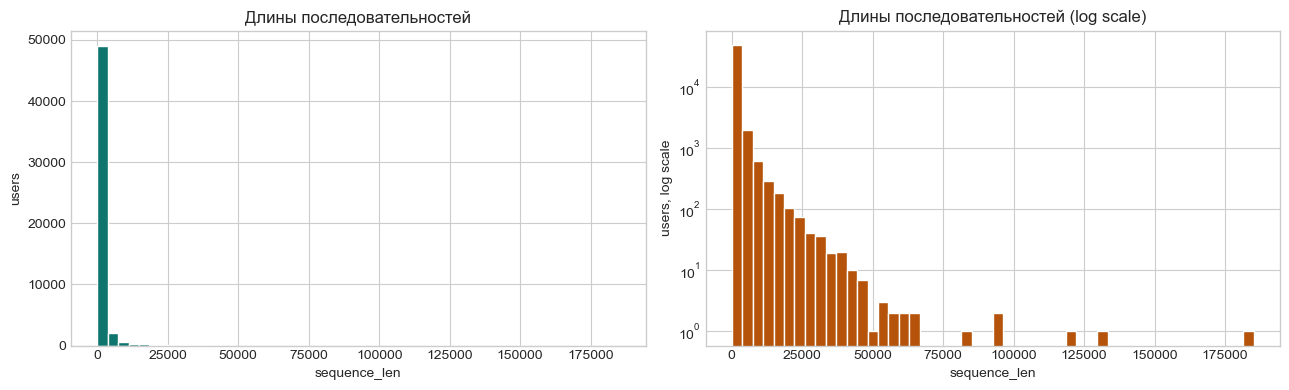

In [9]:
sequence_lengths = [len(seq) for seq in prepared.user_sequences]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(sequence_lengths, bins=50, color='#0f766e', edgecolor='white')
axes[0].set_title('Длины последовательностей')
axes[0].set_xlabel('sequence_len')
axes[0].set_ylabel('users')

axes[1].hist(sequence_lengths, bins=50, color='#b45309', edgecolor='white', log=True)
axes[1].set_title('Длины последовательностей (log scale)')
axes[1].set_xlabel('sequence_len')
axes[1].set_ylabel('users, log scale')

plt.tight_layout()
plt.show()

Вывод.

После фильтра `min_events_per_user = 10` в выборке осталось **52,495** пользователей. Распределение длин историй имеет выраженный тяжёлый хвост: медианная длина последовательности составляет **83** события, тогда как 95-й перцентиль достигает **4,694**, а максимум — **185,204**. Это означает, что полные пользовательские истории слишком неоднородны по длине, и на этапе обучения `RNN` потребуется ограничивать длину входной последовательности, сохраняя при этом наиболее информативную часть поведения пользователя.


## 4. Split по пользователям

Разбиение выполняется только по пользователям, чтобы исключить утечку информации между `train`, `val` и `test`.


In [10]:
split = build_user_split(
    prepared.user_ids,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    seed=SEED,
)

split_summary = describe_user_split(prepared, split)
split_summary

split,users,mean_seq_len,median_seq_len,max_seq_len
str,i64,f64,f64,i64
"""train""",36746,969.5,84.0,185204
"""val""",7874,1001.54,84.0,131726
"""test""",7875,954.94,80.0,64629


Вывод.

Разбиение по пользователям получилось устойчивым: в `train` попало **36,746** пользователей, в `val` — **7,874**, в `test` — **7,875**. Средние длины последовательностей между сплитами близки (`969.5`, `1001.54`, `954.94`), а медианы составляют `84`, `84` и `80` событий соответственно. Это означает, что split не создаёт заметного перекоса по активности пользователей и подходит для дальнейшего честного сравнения моделей.


## 5. Сохранение артефактов preprocessing

Потоковая очистка уже сохранила parquet parts в `artifacts/data/clean_events/`. На этом шаге сохраняются последовательности пользователей и split, которые понадобятся на следующих этапах.


In [11]:
saved_sequences = save_prepared_sequences(prepared, ARTIFACTS_DATA_DIR)
saved_split = save_user_split_tables(prepared, split, ARTIFACTS_DATA_DIR)

saved_paths = {
    **preprocess_paths,
    **saved_sequences,
    **saved_split,
}

saved_paths

{'parts_dir': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/data/clean_events'),
 'summary': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/data/clean_events_summary.csv'),
 'user_sequences': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/data/user_sequences.parquet'),
 'event2idx': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/data/event2idx.json'),
 'sequence_summary': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/data/sequence_summary.csv'),
 'split_json': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/data/split.json'),
 'split_summary': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/data/split_summary.csv'),
 'split_users': PosixPath('/Users/fedornikonov/hse_recsys_rnn/artifacts/data/split_users.parquet')}

In [12]:
sorted(str(path.relative_to(ARTIFACTS_DATA_DIR)) for path in ARTIFACTS_DATA_DIR.rglob('*') if path.is_file())

['clean_events/part_0000.parquet',
 'clean_events/part_0001.parquet',
 'clean_events/part_0002.parquet',
 'clean_events/part_0003.parquet',
 'clean_events/part_0004.parquet',
 'clean_events/part_0005.parquet',
 'clean_events/part_0006.parquet',
 'clean_events/part_0007.parquet',
 'clean_events/part_0008.parquet',
 'clean_events/part_0009.parquet',
 'clean_events/part_0010.parquet',
 'clean_events/part_0011.parquet',
 'clean_events/part_0012.parquet',
 'clean_events/part_0013.parquet',
 'clean_events/part_0014.parquet',
 'clean_events/part_0015.parquet',
 'clean_events/part_0016.parquet',
 'clean_events/part_0017.parquet',
 'clean_events/part_0018.parquet',
 'clean_events/part_0019.parquet',
 'clean_events/part_0020.parquet',
 'clean_events/part_0021.parquet',
 'clean_events/part_0022.parquet',
 'clean_events/part_0023.parquet',
 'clean_events/part_0024.parquet',
 'clean_events/part_0025.parquet',
 'clean_events/part_0026.parquet',
 'clean_events/part_0027.parquet',
 'clean_events/part_

## Итог

На этом этапе построен воспроизводимый preprocessing pipeline для курсовой работы:
- исходный CSV обработан потоково и очищен от технических и служебных событий;
- очищенные события сохранены в `parquet`-частях, что делает дальнейшую работу с данными устойчивой по памяти;
- пользовательские истории преобразованы в последовательности индексов;
- после фильтра по минимальной длине в выборке осталось **52,495** пользователей;
- зафиксирован split по пользователям на `train / val / test`, пригодный для дальнейшей оценки `RNN`-baseline.

Полученные статистики показывают, что данные содержат выраженную неоднородность по активности пользователей и сильный хвост длин последовательностей. Поэтому следующий этап должен быть сосредоточен на `RNN`-baseline с контролируемой длиной входной истории и оценкой на задаче предсказания следующего события.
